In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%gui qt

In [3]:
from pylab import *
from time import sleep
from threading import Thread

# Import Camera:

In [4]:
#raw camera interface modules:
from cameras.alliedvision.VimbaX import VimbaXInterface, VimbaXCamera
from cameras import __version__ as cam_version
print('cam_version:', cam_version)


#For gui interface:
from PySide6.QtWidgets import QApplication
from cameras import pyVimbaX
from cameras.ui import CameraViewport

#Some utilities imports:
from cameras.ui.utilities import crop_roi


cam_version: 0.2.1


# Import SLM:

In [5]:
from slm import LCOS
from slm import __version__ as slm_version
print('slm_version:', slm_version)
from slm.ui.simpleholography.pistoning import PistoningWidget


slm_version: 0.1.0


## Set up camera:

In [6]:
iface = VimbaXInterface()

Camera 0:
--------------------------------
 id     : DEV_1AB22C0B85B0
 name   : Allied Vision 1800 U-040m
 model  : 1800 U-040m
 serial : 0G6NK
 interface : VimbaUSBInterface_0x0
 interface type : TransportLayerType.U3V
 transport layer : AVT USB Transport Layer
 transport layer type: TransportLayerType.U3V
--------------------------------
Camera 1:
--------------------------------
 id     : DEV_Cam1
 name   : Allied Vision Camera Simulator (G1-030_VSWIR)(DEV_Cam1)
 model  : Camera Simulator (G1-030_VSWIR)
 serial : 0D512
 interface : Camera Simulator Interface
 interface type : TransportLayerType.Custom
 transport layer : Camera Simulator TL
 transport layer type: TransportLayerType.Custom
--------------------------------
Camera 2:
--------------------------------
 id     : DEV_Cam2
 name   : Allied Vision Camera Simulator (G1-510c)(DEV_Cam2)
 model  : Camera Simulator (G1-510c)
 serial : 02775
 interface : Camera Simulator Interface
 interface type : TransportLayerType.Custom
 transp

In [7]:
CAM_INDEX = 0  # change as needed
raw = iface._cameras_found[CAM_INDEX]
cam = VimbaXCamera(raw, ring_buffer_size=100, camera_buffer_size=10) #Direct python intertace


In [8]:
#cam.destroy()

In [9]:
viewport_cam = pyVimbaX(cam) #wrap camera into pyVimbaX so viewport understand
viewport_cam.open()
viewport = CameraViewport(viewport_cam)
viewport.show()
viewport.start()


In [10]:
slm = LCOS(screen = 'meadowlark')


Target slm "meadowlark" found with resolution 1920x1152
Display size (Y,X):  1152 1920


In [11]:
pistoning_gui = PistoningWidget(slm)
pistoning_gui.show()

In [12]:
pistoning_gui.level_mode_cb.setChecked(True)
pistoning_gui.h_cut_cb.setChecked(False)
pistoning_gui._region_controls.keys()


dict_keys(['left', 'right'])

# Piston one side:
## (Typically for quick debugging)

In [ ]:
piston_keys = list(pistoning_gui._region_controls.keys())
avr_frames = 25
_wait_time = 0.500
Ih = {}
Iv = {}
def acquiere_LCOS_response(pistonObject, camObject):
    levels = 256
    piston_index = 1 #piston right(0) or left(1)
    pistonObject._region_controls[piston_keys[0]].spin.setValue(256//2 -1)
    sleep(_wait_time)
    Ih[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    Iv[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    print('Pistoning right side:')
    for i in range(levels):
        pistonObject._region_controls[piston_keys[piston_index]].spin.setValue(i)
        sleep(_wait_time)
        frame, _ = camObject.get_tail(avr_frames)
        frame_av = mean(frame, axis=0)
        H_pow = mean(crop_roi(frame_av, viewport._roi_a))
        V_pow = mean(crop_roi(frame_av, viewport._roi_b))
        #print(i, H_pow, V_pow)
        Ih[piston_keys[piston_index]][i] = H_pow
        Iv[piston_keys[piston_index]][i] = V_pow
    
    print('Done')
th = Thread(target=acquiere_LCOS_response, args=(pistoning_gui, cam), daemon=True)
th.start()

Pistoning right side:
Done


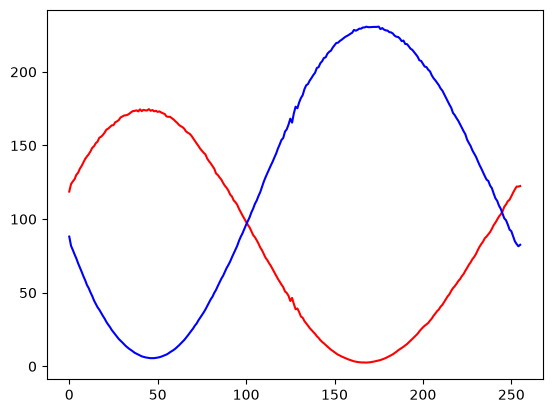

In [63]:
plot(Ih['right'], color =  'red', label = 'H- right')
plot(Iv['right'], color =  'blue', label = 'V- right')


# Piston Both sides:

In [80]:
piston_keys = list(pistoning_gui._region_controls.keys())
avr_frames = 50
_wait_time = 0.750
Ih = {}
Iv = {}
def acquiere_LCOS_response(pistonObject, camObject):
    levels = 256
    piston_index = 1 #piston right(0) or left(1)
    pistonObject._region_controls[piston_keys[0]].spin.setValue(256//2 -1)
    sleep(_wait_time)
    Ih[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    Iv[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    print('Pistoning right side:')
    for i in range(levels):
        pistonObject._region_controls[piston_keys[piston_index]].spin.setValue(i)
        sleep(_wait_time)
        frame, _ = camObject.get_tail(avr_frames)
        frame_av = mean(frame, axis=0)
        H_pow = mean(crop_roi(frame_av, viewport._roi_a))
        V_pow = mean(crop_roi(frame_av, viewport._roi_b))
        #print(i, H_pow, V_pow)
        Ih[piston_keys[piston_index]][i] = H_pow
        Iv[piston_keys[piston_index]][i] = V_pow
    
    #Same but pistoning right side
    piston_index = 0 #piston right(0) or left(1)
    pistonObject._region_controls[piston_keys[1]].spin.setValue(256//2 - 1)
    sleep(_wait_time)
    Ih[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    Iv[piston_keys[piston_index]] =  np.zeros(levels, dtype=np.float32)
    print('Pistoning left side:')
    for i in range(levels):
        pistonObject._region_controls[piston_keys[piston_index]].spin.setValue(i)
        sleep(_wait_time)
        frame, _ = camObject.get_tail(avr_frames)
        frame_av = mean(frame, axis=0)
        H_pow = mean(crop_roi(frame_av, viewport._roi_a))
        V_pow = mean(crop_roi(frame_av, viewport._roi_b))
        #print(i, H_pow, V_pow)
        Ih[piston_keys[piston_index]][i] = H_pow
        Iv[piston_keys[piston_index]][i] = V_pow
    print('Done')
th = Thread(target=acquiere_LCOS_response, args=(pistoning_gui, cam), daemon=True)
th.start()


Pistoning right side:


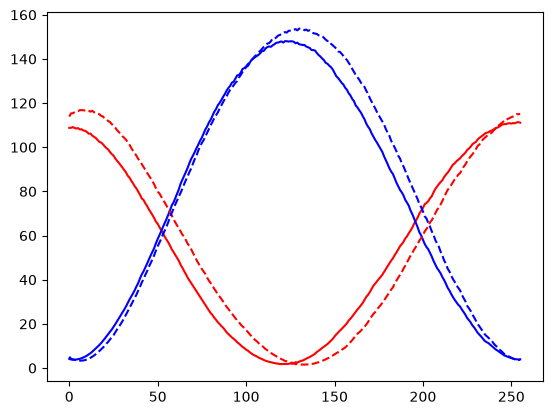

In [82]:
plot(Ih['right'], color =  'red', label = 'H- right')
plot(Iv['right'], color =  'blue', label = 'V- right')
plot(Ih['left'],'--', color =  'red', label = 'H- left')
plot(Iv['left'],'--', color =  'blue', label = 'V- left')

In [65]:
from pathlib import Path
from datetime import datetime
import pickle
import json


In [66]:
experiment = 'experiment_2_LUT_start_phase_0.1'  # user: set new folder name (e.g. experiment_2)
wavelength = '843_5'
coverglassV = '6_2'
LCOS_id = '001'

In [67]:
_config = json.loads((Path('..') / 'config' / 'paths.json').read_text(encoding='utf-8'))
calibration_data_path_root = Path(_config['calibration_data_path_root'])
save_dir = calibration_data_path_root / experiment
save_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y_%m_%d_%H_%M_%S')

cal_label = f'{timestamp}_{wavelength}nm_{coverglassV}mm_LCOS_id_{LCOS_id}.pkl'
save_path = save_dir / cal_label
print(save_path)

C:\Users\ModeLabQBI\LAB\experiments\calibrations\Meadowlark_LUT\data\cam_pol_interference\experiment_2_LUT_start_phase_0.1\2026_08_07_18_48_30_843_5nm_6_2mm_LCOS_id_001.pkl


In [68]:
with open(save_path, 'wb') as f:
    datadump = {'Ih': Ih, 'Iv': Iv}
    pickle.dump(datadump, f)


# Check some data:

In [83]:
from scipy.signal import savgol_filter

def unwrap_phase(phi):
    diff_phase = diff(phi)
    unwPhase = cumsum(r_[0, abs(diff_phase)]) #Add the 0 

    return unwPhase

def norm_I(I):

    I_norm = 2 * (I - I.min()) / (I.max() - I.min()) - 1
    return I_norm

def phase_from_I(I):
    I_filtered =  savgol_filter(I, window_length=11, polyorder=5)
    I_norm = norm_I(I_filtered)
    phase = arccos(I_norm)
    return unwrap_phase(phase)

np.float32(0.042645454)

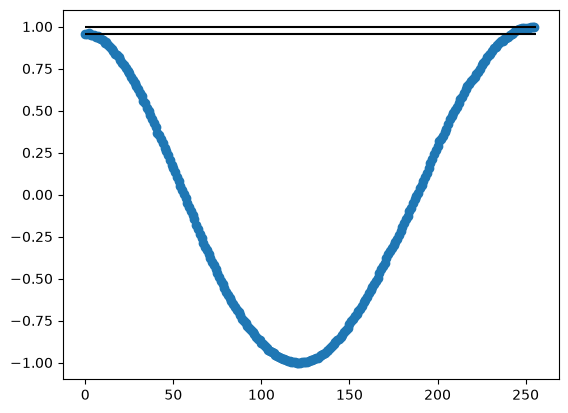

In [84]:
I = Ih['right']
I_min = I.min()
I_max = I.max()
I_norm = 2 * (I - I.min()) / (I.max() - I.min()) - 1
plot(I_norm, 'o')
hlines(I_norm[0], 0, 256, color = 'black')
hlines(I_norm[-1], 0, 256, color = 'black')
abs(I_norm[0] - I_norm[-1])

In [85]:
from scipy.signal import savgol_filter

Range : 0.0 - 6.293559551239014


Text(0, 0.5, 'rad')

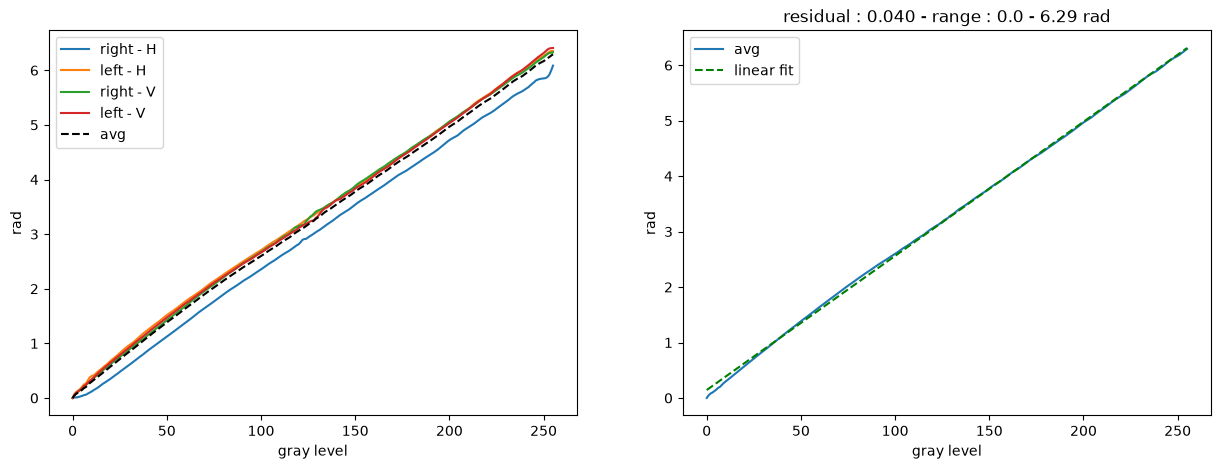

In [86]:
fig, ax = plt.subplots(1,2, figsize = (15,5))

phase_level_slm_response = []
for key, item in Ih.items():
    phase = phase_from_I(item)
    phase_level_slm_response.append(phase)
    ax[0].plot(phase, label = f'{key} - H')

for key, item in Iv.items():
    phase = phase_from_I(item)
    phase_level_slm_response.append(phase)
    ax[0].plot(phase, label = f'{key} - V')

phase_level_slm_response = array(phase_level_slm_response)
phase_level_response_avg = mean(phase_level_slm_response, axis = 0)

ax[0].plot(phase_level_response_avg, '--', color = 'black', label = 'avg')

ax[0].legend()

print(f'Range : {phase_level_response_avg.min()} - {phase_level_response_avg.max()}')

x = linspace(0, 255, 256)
y = polyfit(x, phase_level_response_avg, 1)
phase_fit = polyval(y, x)
ax[1].plot(phase_level_response_avg, label = 'avg')
ax[1].plot(phase_fit, '--', color = 'green', label = 'linear fit')
residual = sqrt(mean((phase_level_response_avg - phase_fit)**2))
ax[1].set_title(f'residual : {residual:0.3f} - range : {phase_level_response_avg.min()} - {phase_level_response_avg.max():0.2f} rad')
ax[1].legend()
ax[0].set_xlabel('gray level')
ax[1].set_xlabel('gray level')
ax[0].set_ylabel('rad')
ax[1].set_ylabel('rad')



In [ ]:
import json
from pathlib import Path

_config = json.loads((Path('..') / 'config' / 'paths.json').read_text(encoding='utf-8'))
calibration_data_path_root = Path(_config['calibration_data_path_root'])
LUT_path_root = Path(_config['LUT_path_root'])

out = LUT_path_root / f"start_cycle_0.1_linearization_test.png"
fig.savefig(out, dpi=150, bbox_inches="tight")